# FinBERT Sentiment Validation and Weekly Market Association

**Academic research only — not investment advice.**

FinBERT scores every distinct financial-news headline in the study window (304,809 headlines → 403,556 events). This notebook rolls those scores up to a **weekly** signal and asks the core question: **does news sentiment move with — or ahead of — the broad market?**

This notebook validates the completed FinBERT sentiment scores and performs an exploratory weekly analysis. It asks whether aggregate financial-news sentiment moves with or leads a broad sector-ETF market proxy.

**Leakage control.** FinBERT receives only the supplied headline text and is not given prices, returns, tickers, dates, or future outcomes. This prevents direct target leakage during inference. Possible information retained through model pretraining cannot be completely ruled out and remains a project limitation.

This is a diagnostic step before the final predictive model. The project's main research question—whether FinBERT sentiment adds incremental out-of-sample predictive value for next-session sector ETF direction—is tested in the final model-comparison notebook.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 110
FB, RP = "#1f77b4", "#ff7f0e"   # FinBERT / RavenPack colors
UP, DN = "#2ca02c", "#d62728"

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data_collection").exists() and (REPO_ROOT.parent / "data_collection").exists():
    REPO_ROOT = REPO_ROOT.parent
RAW = REPO_ROOT / "data_collection" / "raw"
DC = REPO_ROOT / "data_collection"

scores = pd.read_csv(RAW / "finbert_scores.csv")          # text_id, label, sentiment, confidence
event_map = pd.read_csv(RAW / "llm_scoring_event_map.csv") # text_id, signal_calendar_date, event_sentiment_score
market = pd.read_csv(DC / "market_daily_df.csv")           # session_date, ticker, daily_return, ...

# one row per news event, carrying FinBERT + RavenPack sentiment and a lookahead-safe date
scores = pd.read_csv(
    RAW / "finbert_scores.csv"
)

event_map = pd.read_csv(
    RAW / "llm_scoring_event_map.csv"
)

market = pd.read_csv(
    DC / "market_daily_df.csv",
    parse_dates=["session_date"]
)

# Validate FinBERT score file.
assert scores["text_id"].is_unique, "Duplicate text_id values found in FinBERT scores."

# Every event should match no more than one FinBERT score.
ev = event_map.merge(
    scores[["text_id", "sentiment", "label", "confidence"]],
    on="text_id",
    how="left",
    validate="many_to_one",
)

ev = ev.rename(
    columns={
        "sentiment": "fb_sent",
        "label": "fb_label",
        "confidence": "fb_confidence",
        "event_sentiment_score": "rp_sent",
    }
)

ev["signal_calendar_date"] = pd.to_datetime(
    ev["signal_calendar_date"]
)

# Check scoring coverage before continuing.
score_coverage = ev["fb_sent"].notna().mean()

print(f"Event rows: {len(ev):,}")
print(f"FinBERT score coverage: {score_coverage:.2%}")

assert score_coverage > 0.99, (
    f"FinBERT coverage is only {score_coverage:.2%}. "
    "Complete scoring before running this notebook."
)

# Map every signal calendar date to the next actual market session.
trading_sessions = (
    market[["session_date"]]
    .drop_duplicates()
    .sort_values("session_date")
)

ev = pd.merge_asof(
    ev.sort_values("signal_calendar_date"),
    trading_sessions,
    left_on="signal_calendar_date",
    right_on="session_date",
    direction="forward",
)

ev = ev.dropna(subset=["session_date"]).copy()

# Use trading weeks ending Friday.
ev["week"] = ev["session_date"].dt.to_period("W-FRI")

print(
    f"Events after session mapping: {len(ev):,} | "
    f"session range: {ev['session_date'].min().date()} "
    f"to {ev['session_date'].max().date()}"
)

Event rows: 403,556
FinBERT score coverage: 100.00%
Events after session mapping: 403,533 | session range: 2020-01-02 to 2025-12-31


## 1. Weekly sentiment

Each news event is assigned to its (lookahead-safe) week. The weekly signal is the average FinBERT sentiment across that week's events (so busier news weeks are naturally event-weighted), alongside the positive/negative label shares and news volume.

In [2]:
wk_sent = (
    ev.groupby("week")
    .agg(
        fb_sent=("fb_sent", "mean"),
        rp_sent=("rp_sent", "mean"),
        event_rows=("text_id", "size"),
        scored_events=("fb_sent", "count"),
        unique_texts=("text_id", "nunique"),
        mean_confidence=("fb_confidence", "mean"),
        pos_share=("fb_label", lambda s: (s == "positive").mean()),
        neg_share=("fb_label", lambda s: (s == "negative").mean()),
        neutral_share=("fb_label", lambda s: (s == "neutral").mean()),
    )
    .reset_index()
)

wk_sent["score_coverage"] = (
    wk_sent["scored_events"] / wk_sent["event_rows"]
)

wk_sent["net_tone"] = (
    wk_sent["pos_share"] - wk_sent["neg_share"]
)

print(f"Weeks: {len(wk_sent):,}")
display(wk_sent.tail())

Weeks: 314


,week,fb_sent,rp_sent,event_rows,scored_events,unique_texts,mean_confidence,pos_share,neg_share,neutral_share,score_coverage,net_tone
309,2025-11-29/2025-12-05,0.091232,0.082833,1387,1387,1068,0.799320,0.374910,0.279019,0.346071,1.0,0.095890
310,2025-12-06/2025-12-12,0.101775,0.098386,1437,1437,1089,0.808095,0.409882,0.279054,0.311065,1.0,0.130828
311,2025-12-13/2025-12-19,0.018125,0.076337,1589,1589,1225,0.808166,0.360604,0.337319,0.302077,1.0,0.023285
312,2025-12-20/2025-12-26,0.158824,0.118113,885,885,648,0.805474,0.464407,0.247458,0.288136,1.0,0.216949
313,2025-12-27/2026-01-02,-0.052164,0.064590,488,488,361,0.814651,0.311475,0.364754,0.323770,1.0,-0.053279


## 2. Weekly market return

A broad-market proxy: the equal-weight average daily return across the 11 SPDR sector ETFs, compounded within each week. Same weekly buckets as the sentiment series.

In [3]:
market["session_date"] = pd.to_datetime(
    market["session_date"]
)

daily_mkt = (
    market.groupby("session_date", as_index=False)
    .agg(
        daily_return=("daily_return", "mean"),
        sector_count=("ticker", "nunique"),
    )
)

daily_mkt["week"] = (
    daily_mkt["session_date"].dt.to_period("W-FRI")
)

wk_mkt = (
    daily_mkt.groupby("week")
    .agg(
        mkt_return=(
            "daily_return",
            lambda r: (1 + r).prod() - 1,
        ),
        trading_sessions=("session_date", "nunique"),
        sector_count=("sector_count", "min"),
    )
    .reset_index()
)

w = (
    wk_sent.merge(
        wk_mkt,
        on="week",
        how="inner",
        validate="one_to_one",
    )
    .sort_values("week")
    .reset_index(drop=True)
)

w["week_start"] = w["week"].dt.start_time
w["week_end"] = w["week"].dt.end_time.dt.normalize()

last_market_date = market["session_date"].max()

w = w.loc[
    w["week_end"] <= last_market_date
].copy()

w["mkt_return_next"] = w["mkt_return"].shift(-1)

print(
    f"Aligned complete weeks: {len(w):,} "
    f"({w['week_start'].min().date()} "
    f"to {w['week_end'].max().date()})"
)

Aligned complete weeks: 313 (2019-12-28 to 2025-12-26)


## 3. Sentiment and the market over time

Weekly FinBERT sentiment (line) against the weekly broad-market return (green/red bars). The COVID crash of early 2020 is the clearest stress test — sentiment should crater alongside returns.

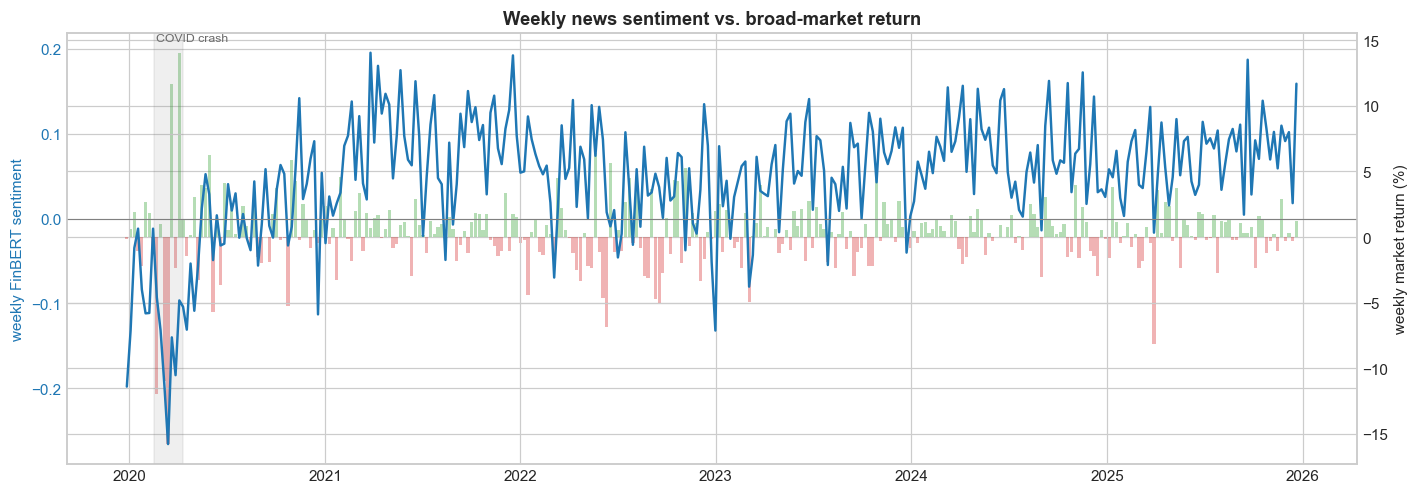

In [4]:
fig, ax = plt.subplots(figsize=(13, 4.6))
ax2 = ax.twinx()

colors = [UP if r >= 0 else DN for r in w["mkt_return"]]
ax2.bar(w["week_start"], w["mkt_return"] * 100, width=6, color=colors, alpha=0.35, label="market return")
ax.plot(w["week_start"], w["fb_sent"], color=FB, lw=1.6, label="FinBERT sentiment")
ax.axhline(0, color="grey", lw=0.7)
ax.axvspan(pd.Timestamp("2020-02-17"), pd.Timestamp("2020-04-10"), color="grey", alpha=0.12)
ax.text(pd.Timestamp("2020-02-20"), ax.get_ylim()[1], "COVID crash", fontsize=8, va="top", color="dimgray")

ax.set_ylabel("weekly FinBERT sentiment", color=FB)
ax2.set_ylabel("weekly market return (%)")
ax.set_zorder(ax2.get_zorder() + 1); ax.patch.set_visible(False)
ax.set_title("Weekly news sentiment vs. broad-market return", fontweight="bold")
ax.tick_params(axis="y", colors=FB)
fig.tight_layout()
plt.show()

## 4. Macro-news volume

This figure shows the number of filtered RavenPack macro-news events in each week. Volume spikes indicate high-attention periods, but high news volume alone does not imply stronger predictive information.

In [5]:
comparison = ev.dropna(
    subset=["fb_sent", "rp_sent"]
).copy()

comparison["rp_label"] = np.select(
    [
        comparison["rp_sent"] > 0.05,
        comparison["rp_sent"] < -0.05,
    ],
    [
        "positive",
        "negative",
    ],
    default="neutral",
)

event_corr = comparison["fb_sent"].corr(
    comparison["rp_sent"]
)

sign_agreement = (
    comparison["fb_label"] == comparison["rp_label"]
).mean()

weekly_corr = w["fb_sent"].corr(
    w["rp_sent"]
)

print(f"Event-level Pearson correlation: {event_corr:.3f}")
print(f"Event-level label agreement: {sign_agreement:.1%}")
print(f"Weekly Pearson correlation: {weekly_corr:.3f}")

Event-level Pearson correlation: 0.433
Event-level label agreement: 56.9%
Weekly Pearson correlation: 0.714


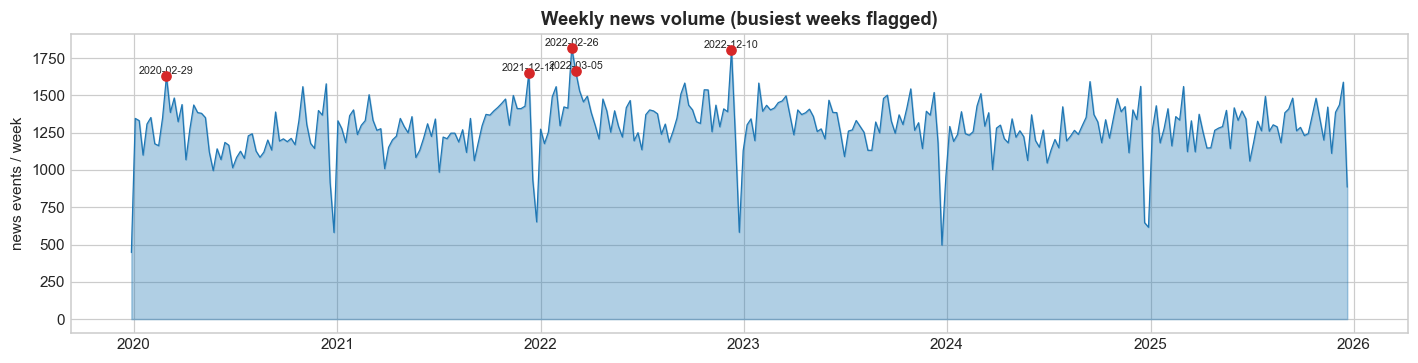

In [7]:
fig, ax = plt.subplots(figsize=(13, 3.4))
ax.fill_between(w["week_start"], w["event_rows"], color=FB, alpha=0.35)
ax.plot(w["week_start"], w["event_rows"], color=FB, lw=0.8)
top = w.nlargest(5, "event_rows")
ax.scatter(top["week_start"], top["event_rows"], color=DN, zorder=5)
for _, r in top.iterrows():
    ax.annotate(r["week_start"].strftime("%Y-%m-%d"), (r["week_start"], r["event_rows"]),
                fontsize=7, ha="center", va="bottom")
ax.set_ylabel("news events / week")
ax.set_title("Weekly news volume (busiest weeks flagged)", fontweight="bold")
fig.tight_layout()
plt.show()

## 5. Does sentiment move with the market — or ahead of it?

Left: this week's sentiment vs. **this week's** return (co-movement). Right: this week's sentiment vs. **next week's** return (does sentiment *lead*?). Co-movement is expected — news describes what's happening. The interesting, harder question is whether any *predictive* signal survives into the following week.

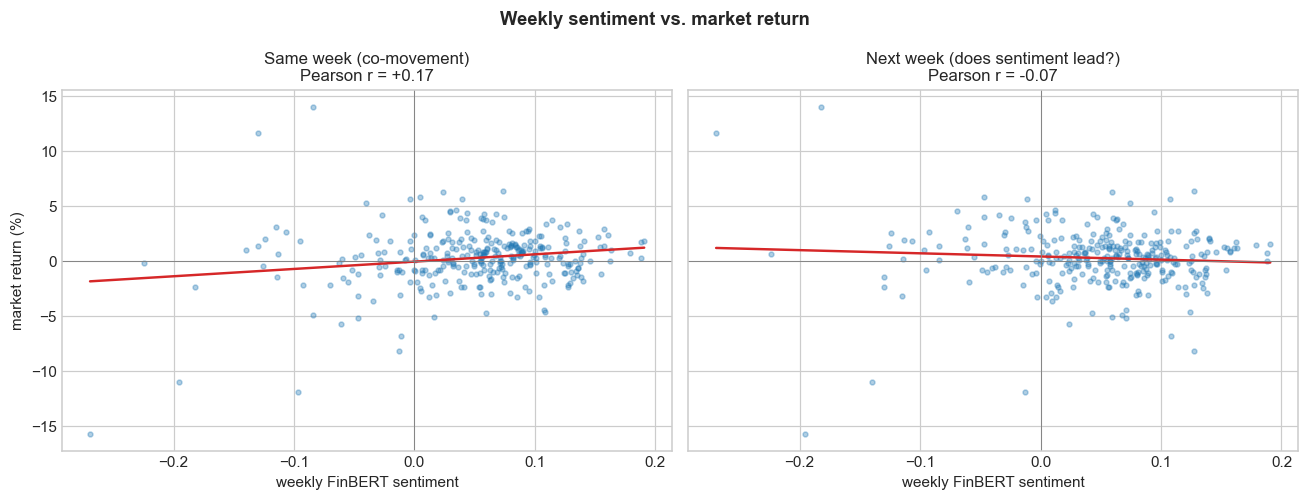

In [6]:
def scatter(ax, x, y, title):
    m = x.notna() & y.notna()
    x, y = x[m], y[m]
    ax.scatter(x, y * 100, s=10, alpha=0.35, color=FB)
    b, a = np.polyfit(x, y * 100, 1)
    xs = np.linspace(x.min(), x.max(), 50)
    ax.plot(xs, a + b * xs, color=DN, lw=1.6)
    ax.axhline(0, color="grey", lw=0.6); ax.axvline(0, color="grey", lw=0.6)
    ax.set_title(f"{title}\nPearson r = {x.corr(y):+.2f}", fontsize=11)
    ax.set_xlabel("weekly FinBERT sentiment")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
scatter(axes[0], w["fb_sent"], w["mkt_return"], "Same week (co-movement)")
scatter(axes[1], w["fb_sent"], w["mkt_return_next"], "Next week (does sentiment lead?)")
axes[0].set_ylabel("market return (%)")
fig.suptitle("Weekly sentiment vs. market return", fontweight="bold")
fig.tight_layout()
plt.show()

## 6. Lead–lag structure

Correlation of this week's sentiment with the market return *k* weeks away. **k = 0** is co-movement; **k > 0** means sentiment *leads* returns (a predictive signal); **k < 0** means returns lead sentiment (news reacts to the market). A tall bar at k = 0 that collapses for k > 0 is the classic "news reflects, doesn't predict" pattern — and the honest read on whether this signal can trade.

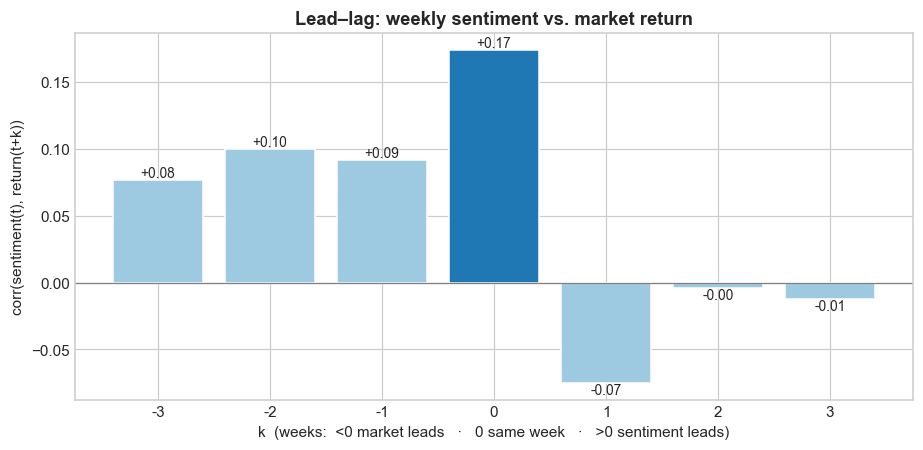

In [7]:
ks = range(-3, 4)
corrs = [w["fb_sent"].corr(w["mkt_return"].shift(-k)) for k in ks]
fig, ax = plt.subplots(figsize=(8.5, 4.2))
bars = ax.bar([str(k) for k in ks], corrs,
              color=["#9ecae1" if k != 0 else FB for k in ks], edgecolor="white")
for k, c in zip(ks, corrs):
    ax.text(k + 3, c, f"{c:+.2f}", ha="center", va="bottom" if c >= 0 else "top", fontsize=9)
ax.axhline(0, color="grey", lw=0.8)
ax.set_xlabel("k  (weeks:  <0 market leads   ·   0 same week   ·   >0 sentiment leads)")
ax.set_ylabel("corr(sentiment(t), return(t+k))")
ax.set_title("Lead–lag: weekly sentiment vs. market return", fontweight="bold")
fig.tight_layout()
plt.show()

## 7. FinBERT vs. RavenPack at weekly resolution

Both weekly sentiment series overlaid. Tight tracking means the free, local FinBERT reproduces RavenPack's proprietary score at the aggregate level; divergences are where the two disagree — a first-class finding for the report.

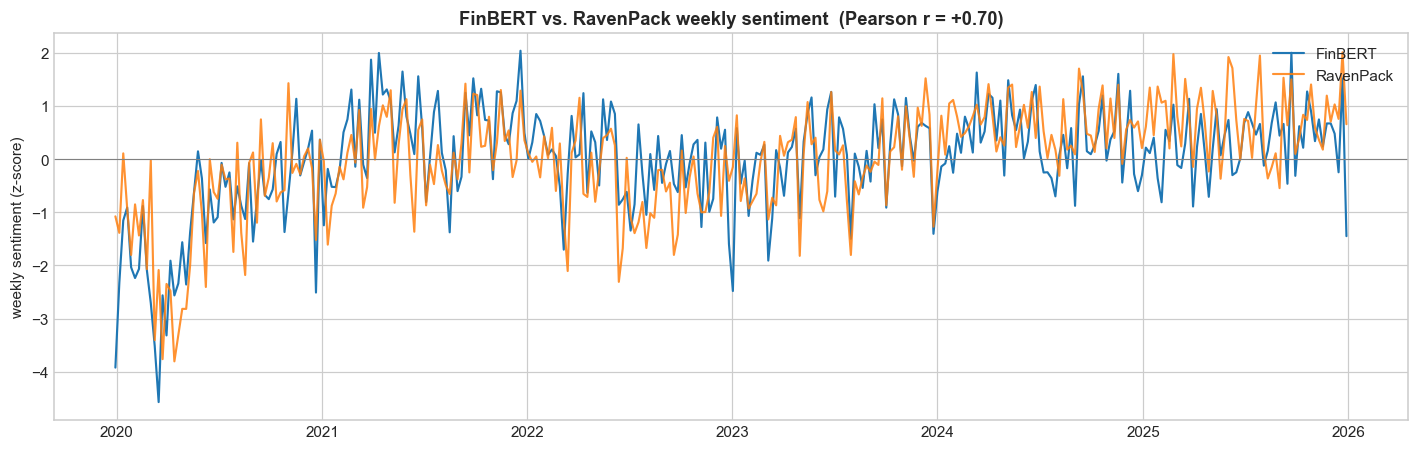

In [8]:
fig, ax = plt.subplots(figsize=(13, 4.2))
fb_z = (w["fb_sent"] - w["fb_sent"].mean()) / w["fb_sent"].std()
rp_z = (w["rp_sent"] - w["rp_sent"].mean()) / w["rp_sent"].std()
ax.plot(w["week_start"], fb_z, color=FB, lw=1.4, label="FinBERT")
ax.plot(w["week_start"], rp_z, color=RP, lw=1.4, alpha=0.85, label="RavenPack")
ax.axhline(0, color="grey", lw=0.7)
ax.set_ylabel("weekly sentiment (z-score)")
ax.set_title(f"FinBERT vs. RavenPack weekly sentiment  (Pearson r = {w['fb_sent'].corr(w['rp_sent']):+.2f})",
             fontweight="bold")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

## 8. Conclusions and handoff to modeling

This notebook provides a validation and exploratory summary of the FinBERT signal.

The main findings to report are:

1. FinBERT scoring coverage and score distributions are sufficient for downstream analysis.
2. FinBERT and RavenPack can be compared at both the event and weekly levels.
3. Same-week association measures whether sentiment reflects current market conditions.
4. Lead-lag analysis provides preliminary evidence about whether weekly sentiment precedes returns, but it is not the final predictive test.
5. Weekly aggregation may hide sector-specific and daily information, so final conclusions must come from the next-session walk-forward model.

The next notebook will map every event to an actual trading session, aggregate FinBERT scores into daily model features, and join those features to the 11-sector-ETF panel.
